In [1]:
from kernels import PhysKerBase, PhysKerGP
from priors import SquExpKernel
from sympy import *
import numpy as np

In [2]:
squexp = SquExpKernel(2) # Specifying the prior on u(x,t) ~ GP(0, SquExp)
L = sympify("- a*Derivative(u, x0, 2)") # Specifying the linear operator

b_ops = [sympify("Derivative(u, x0)"), sympify("Derivative(u, x0)")]
b_conds = [lambda x0,x1: x0==0, lambda x0,x1: x0==1]

In [3]:
phys_kernel = PhysKerBase(squexp, L, b_ops, b_conds)

In [4]:
X_u = np.column_stack((np.random.uniform(0,1,size=5), np.random.uniform(0,1,size=5)))
X_f = np.column_stack((np.random.uniform(0,1,size=5), np.random.uniform(0,1,size=5)))
X = (X_u, X_f)

In [5]:
np.vstack((X_u, X_f))

array([[0.16136101, 0.35488847],
       [0.13738664, 0.57715082],
       [0.81449501, 0.55799478],
       [0.83390193, 0.59484648],
       [0.33319572, 0.66782451],
       [0.23079394, 0.97208391],
       [0.91979484, 0.40374694],
       [0.17286092, 0.28505907],
       [0.84400872, 0.76088801],
       [0.51336676, 0.10871807]])

In [8]:
K = phys_kernel.K_func(X)
K({"a":5, "w0":10, "w1":1, "s":1}, phys_kernel.kernel_dictionary(), sigma=(0,0))

array([[ 1.00000000e+00,  9.72802568e-01,  1.16071814e-01,
         1.01231390e-01,  8.21518919e-01,  3.83994490e+01,
        -1.33742558e+01,  4.97793550e+01, -1.63962135e+01,
        -6.24154510e+00],
       [ 9.72802568e-01,  1.00000000e+00,  1.01007327e-01,
         8.84052114e-02,  8.22162813e-01,  4.04117222e+01,
        -1.18182803e+01,  4.70122399e+01, -1.61698645e+01,
        -9.14011166e+00],
       [ 1.16071814e-01,  1.01007327e-01,  1.00000000e+00,
         9.97441112e-01,  3.12148468e-01, -2.01089177e+01,
         4.15610256e+01, -1.91663714e+01,  4.83437103e+01,
         2.67751768e+00],
       [ 1.01231390e-01,  8.84052114e-02,  9.97441112e-01,
         1.00000000e+00,  2.84734963e-01, -1.99247653e+01,
         4.38264029e+01, -1.80654628e+01,  4.92399547e+01,
        -7.29028140e-01],
       [ 8.21518919e-01,  8.22162813e-01,  3.12148468e-01,
         2.84734963e-01,  1.00000000e+00,  4.05497231e+01,
        -2.10955820e+01,  3.03584621e+01, -2.17332167e+01,
         2.

### 1d HEAT EQUATION

In [9]:
def index_concat(u, f):
    u_indexed = np.column_stack((np.zeros(u.shape[0]), u))
    f_indexed = np.column_stack((np.ones(f.shape[0]), f))

    return np.vstack((u_indexed, f_indexed))

In [10]:
squexp = SquExpKernel(1) # Specifying the prior on u(x,t) ~ GP(0, SquExp)
L = sympify("-a*Derivative(u, x0, 2)") # Specifying the linear operator
phys_kernel = PhysKerBase(squexp, L)

In [11]:
phys_kernel_gp = PhysKerGP(phys_kernel, 
                           {"a":1, "w0":0.5, "s":0.5}, 
                           {"a":(1.0,1.0), "w0":(-100,100), "s":(0.1,10)})

In [12]:
true_f = np.vectorize(lambda x : (4*np.pi**2)*np.sin(2*np.pi*x))
true_u = np.vectorize(lambda x : np.sin(2*np.pi*x))

In [13]:
np.random.seed(3)

N_u = 2
N_f = 7

u_obs = np.array([0,1])

a,b = 0,1
n_f = N_f-1
indexes = np.arange(0,n_f+1)

f_obs = (a+b)/2 + ((b-a)/2)*np.cos(np.pi*indexes/n_f)

In [8]:
index_concat(u_obs, f_obs)

array([[0.       , 0.       ],
       [0.       , 1.       ],
       [1.       , 1.       ],
       [1.       , 0.9330127],
       [1.       , 0.75     ],
       [1.       , 0.5      ],
       [1.       , 0.25     ],
       [1.       , 0.0669873],
       [1.       , 0.       ]])

In [9]:
X = index_concat(u_obs, f_obs)
X_u = X[X[:,0]==0][:,1:]
X_f = X[X[:,0]==1][:,1:]
print(X_u)
print(X_f)  

[[0.]
 [1.]]
[[1.       ]
 [0.9330127]
 [0.75     ]
 [0.5      ]
 [0.25     ]
 [0.0669873]
 [0.       ]]


In [14]:
X = np.linspace(0, 1, 50)
phys_kernel_gp(index_concat(u_obs, f_obs),np.column_stack((np.zeros((50,1)), X))).shape

(50, 9)

In [12]:
np.hstack(([[0., 1.]], [[1. ,       0.9330127, 0.75 ,     0.5       , 0.25      , 0.0669873, 0.       ]]))

array([[0.       , 1.       , 1.       , 0.9330127, 0.75     , 0.5      ,
        0.25     , 0.0669873, 0.       ]])

In [8]:
from sklearn.gaussian_process import GaussianProcessRegressor

gp = GaussianProcessRegressor(kernel=phys_kernel_gp,
                              random_state=2,
                              alpha=1e-6,
                              n_restarts_optimizer=2)

y = np.hstack((true_u(u_obs), true_f(f_obs)))
gp.fit(index_concat(u_obs, f_obs), y)

c:\Users\marku\physgp\physgp\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter s is close to the specified lower bound 0.1. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\marku\physgp\physgp\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter s is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".","PhysKerGP(1, 0.5, 0.5)"
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-06
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",2
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`Glossar

In [9]:
gp.kernel_.param_values

{'a': np.float64(1.0),
 'w0': np.float64(100.0),
 's': np.float64(0.14213528695826133)}

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 9 is different from 100)

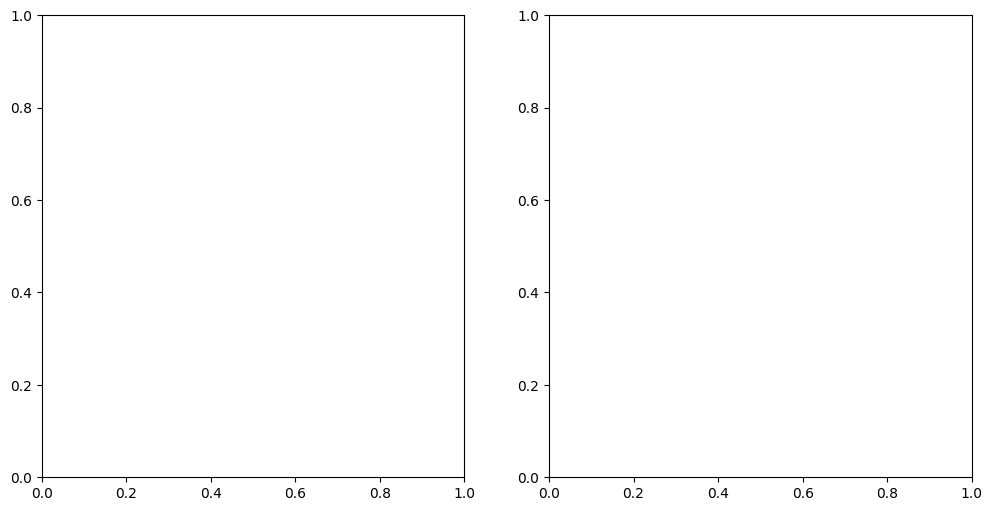

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,2,figsize=(12,6))

N_plot = 100
X = np.linspace(0, 1, N_plot)

# U_prediction
u_mean_prediction, u_std_prediction = gp.predict(np.column_stack((np.zeros((N_plot,1)), X)), return_cov=True)
u_std_prediction = np.diagonal(u_std_prediction)
ax[0].plot(X, u_mean_prediction, label="Mean u")
ax[0].fill_between(X, u_mean_prediction-1.96*u_std_prediction, u_mean_prediction+1.96*u_std_prediction, alpha=0.2)
ax[0].plot(X, true_u(X), label="True u")
ax[0].scatter(u_obs, true_u(u_obs), label="Obs", marker='+', color="black")
ax[0].legend(loc="lower left")

# F_prediction
f_mean_prediction, f_std_prediction = gp.predict(np.column_stack((np.ones((N_plot,1)), X)), return_cov=True)
f_std_prediction = np.diagonal(f_std_prediction)
ax[1].plot(X, f_mean_prediction, label="Mean f")
ax[1].fill_between(X, f_mean_prediction-1.96*f_std_prediction, f_mean_prediction+1.96*f_std_prediction, alpha=0.2)
ax[1].plot(X, true_f(X), label="True u")
ax[1].scatter(f_obs, true_f(f_obs), label="Obs", marker='+', color="black")
ax[1].legend(loc="lower left")

plt.show()

In [11]:
u_mean_prediction

array([-1.24186260e-06,  1.01397158e-02,  1.97419573e-02,  2.83067920e-02,
        3.54234180e-02,  4.08125999e-02,  4.43602363e-02,  4.61364193e-02,
        4.63968453e-02,  4.55651648e-02,  4.41968767e-02,  4.29274476e-02,
        4.24092361e-02,  4.32432710e-02,  4.59127857e-02,  5.07255188e-02,
        5.77711048e-02,  6.68984665e-02,  7.77161194e-02,  8.96159367e-02,
        1.01818463e-01,  1.13435603e-01,  1.23544690e-01,  1.31266783e-01,
        1.35841674e-01,  1.36692516e-01,  1.33474189e-01,  1.26101287e-01,
        1.14753785e-01,  9.98607009e-02,  8.20642152e-02,  6.21684556e-02,
        4.10783893e-02,  1.97348219e-02, -9.48576041e-04, -2.01409822e-02,
       -3.71388065e-02, -5.13961445e-02, -6.25402894e-02, -7.03728196e-02,
       -7.48580890e-02, -7.61019299e-02, -7.43239625e-02, -6.98270807e-02,
       -6.29674838e-02, -5.41281037e-02, -4.36975337e-02, -3.20556901e-02,
       -1.95665245e-02, -6.57724440e-03,  6.57724440e-03,  1.95665245e-02,
        3.20556901e-02,  